In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

In [31]:
df= pd.read_csv("wine.csv")
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


Text(0, 0.5, 'malic')

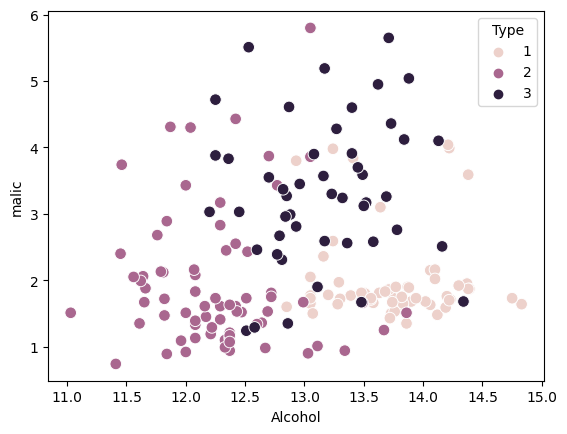

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x = df['Alcohol'], y = df['Malic'], hue=df['Type'],s=70)
plt.xlabel('Alcohol')
plt.ylabel('malic')

Text(0, 0.5, 'Alcalinity')

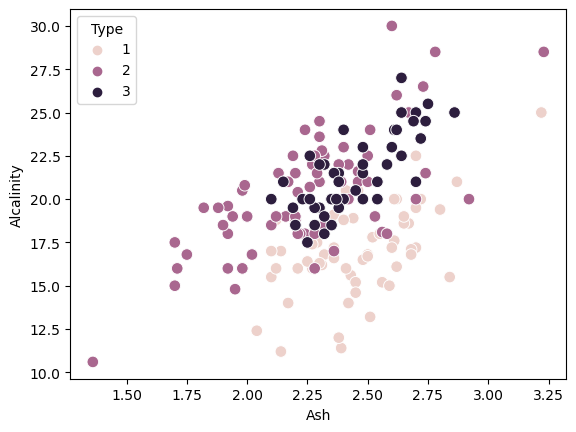

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x = df['Ash'], y = df['Alcalinity'], hue=df['Type'],s=70)
plt.xlabel('Ash')
plt.ylabel('Alcalinity')

Text(0, 0.5, 'Phenols')

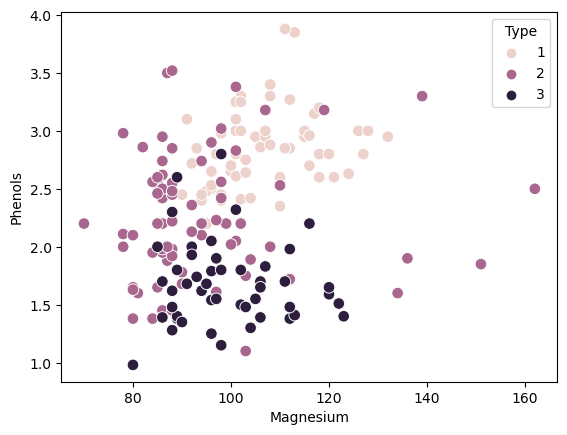

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x = df['Magnesium'], y = df['Phenols'], hue=df['Type'],s=70)
plt.xlabel('Magnesium')
plt.ylabel('Phenols')

Text(0, 0.5, 'Nonflavanoids')

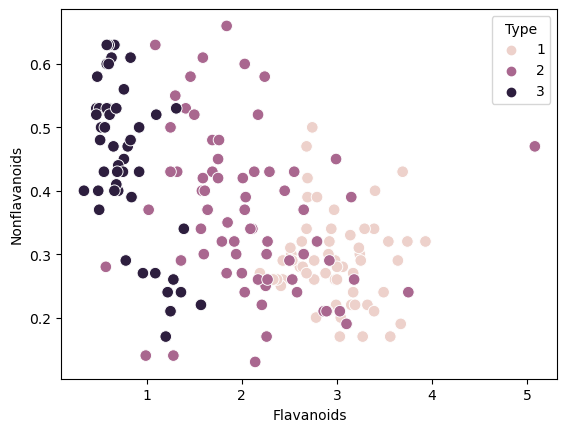

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x = df['Flavanoids'], y = df['Nonflavanoids'], hue=df['Type'],s=70)
plt.xlabel('Flavanoids')
plt.ylabel('Nonflavanoids')

Text(0, 0.5, 'Color')

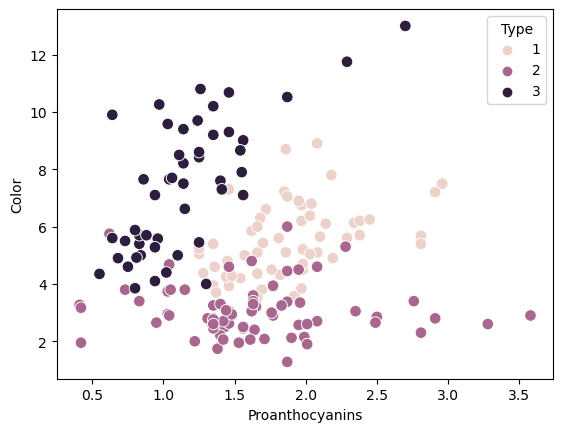

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x = df['Proanthocyanins'], y = df['Color'], hue=df['Type'],s=70)
plt.xlabel('Proanthocyanins')
plt.ylabel('Color')

Text(0, 0.5, 'Dilution')

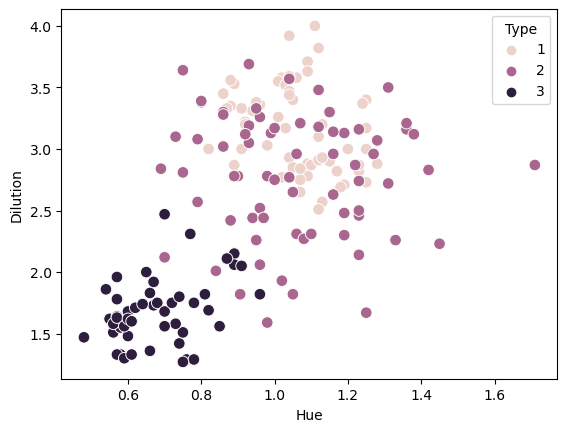

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x = df['Hue'], y = df['Dilution'], hue=df['Type'],s=70)
plt.xlabel('Hue')
plt.ylabel('Dilution')

In [38]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [39]:
data = df.drop(columns=["Type"])
data

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [40]:
x = df.drop(columns=['Type'])
y = df.iloc[:,:1]

In [41]:
x

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [42]:
y

,Type
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


In [45]:
SS = StandardScaler()                
x= SS.fit_transform(x)
x

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [47]:
pca = PCA()
PCS = pca.fit_transform(x)
PCS
pd.DataFrame(PCS)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,3.316751,-1.443463,-0.165739,-0.215631,0.693043,-0.223880,0.596427,0.065139,0.641443,1.020956,-0.451563,0.540810,-0.066239
1,2.209465,0.333393,-2.026457,-0.291358,-0.257655,-0.927120,0.053776,1.024416,-0.308847,0.159701,-0.142657,0.388238,0.003637
2,2.516740,-1.031151,0.982819,0.724902,-0.251033,0.549276,0.424205,-0.344216,-1.177834,0.113361,-0.286673,0.000584,0.021717
3,3.757066,-2.756372,-0.176192,0.567983,-0.311842,0.114431,-0.383337,0.643593,0.052544,0.239413,0.759584,-0.242020,-0.369484
4,1.008908,-0.869831,2.026688,-0.409766,0.298458,-0.406520,0.444074,0.416700,0.326819,-0.078366,-0.525945,-0.216664,-0.079364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-3.370524,-2.216289,-0.342570,1.058527,-0.574164,-1.108788,0.958416,-0.146097,-0.022498,-0.304117,0.139228,0.170786,-0.114427
174,-2.601956,-1.757229,0.207581,0.349496,0.255063,-0.026465,0.146894,-0.552427,-0.097969,-0.206061,0.258198,-0.279431,-0.187371
175,-2.677839,-2.760899,-0.940942,0.312035,1.271355,0.273068,0.679235,0.047024,0.001222,-0.247997,0.512492,0.698766,0.072078
176,-2.387017,-2.297347,-0.550696,-0.688285,0.813955,1.178783,0.633975,0.390829,0.057448,0.491490,0.299822,0.339821,-0.021866


Text(0.5, 1.0, 'Scree Plot')

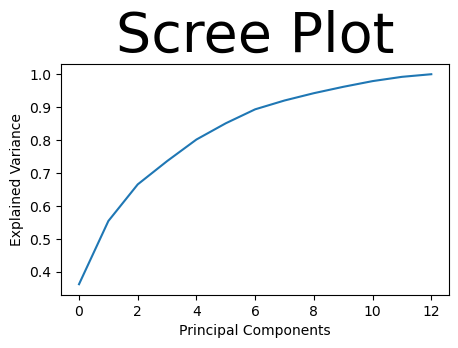

In [50]:
pca.explained_variance_ratio_
plt.figure(figsize=(5,3),dpi=100)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot', size = 40)

In [56]:
pca = PCA(n_components=5)      #we mwntion that the no of components i.e. 2
PCS = pca.fit_transform(x)
PCS
data = pd.DataFrame(PCS,columns=['PC1','PC2','PC3','PC4','PC5'])
data

,PC1,PC2,PC3,PC4,PC5
0,3.316751,-1.443463,-0.165739,-0.215631,0.693043
1,2.209465,0.333393,-2.026457,-0.291358,-0.257655
2,2.516740,-1.031151,0.982819,0.724902,-0.251033
3,3.757066,-2.756372,-0.176192,0.567983,-0.311842
4,1.008908,-0.869831,2.026688,-0.409766,0.298458
...,...,...,...,...,...
173,-3.370524,-2.216289,-0.342570,1.058527,-0.574164
174,-2.601956,-1.757229,0.207581,0.349496,0.255063
175,-2.677839,-2.760899,-0.940942,0.312035,1.271355
176,-2.387017,-2.297347,-0.550696,-0.688285,0.813955


In [58]:
data['Type'] = y
data

,PC1,PC2,PC3,PC4,PC5,Type
0,3.316751,-1.443463,-0.165739,-0.215631,0.693043,1
1,2.209465,0.333393,-2.026457,-0.291358,-0.257655,1
2,2.516740,-1.031151,0.982819,0.724902,-0.251033,1
3,3.757066,-2.756372,-0.176192,0.567983,-0.311842,1
4,1.008908,-0.869831,2.026688,-0.409766,0.298458,1
...,...,...,...,...,...,...
173,-3.370524,-2.216289,-0.342570,1.058527,-0.574164,3
174,-2.601956,-1.757229,0.207581,0.349496,0.255063,3
175,-2.677839,-2.760899,-0.940942,0.312035,1.271355,3
176,-2.387017,-2.297347,-0.550696,-0.688285,0.813955,3


<Axes: xlabel='PC1', ylabel='PC2'>

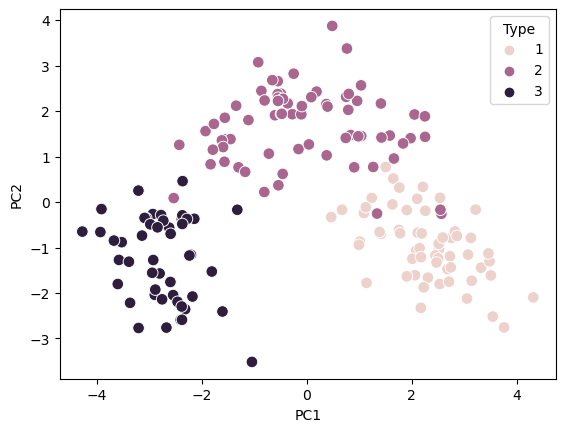

In [60]:
sns.scatterplot(x = data['PC1'], y = data['PC2'], hue=df['Type'],s=70)

<Axes: xlabel='PC3', ylabel='PC4'>

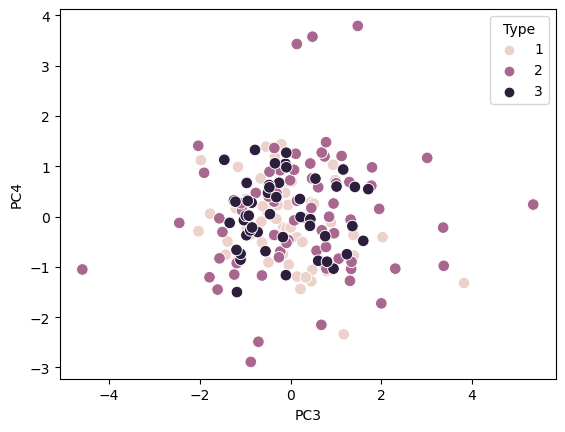

In [61]:
sns.scatterplot(x = data['PC3'], y = data['PC4'], hue=df['Type'],s=70)

In [65]:
x = data.iloc[:,:-1]
y = data['Type']
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2, random_state=1)
LG = LogisticRegression()                
LG.fit(xtrain,ytrain)
ypred = LG.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        13
           3       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score: 0.3094
Davies-Bouldin Index: 1.2949


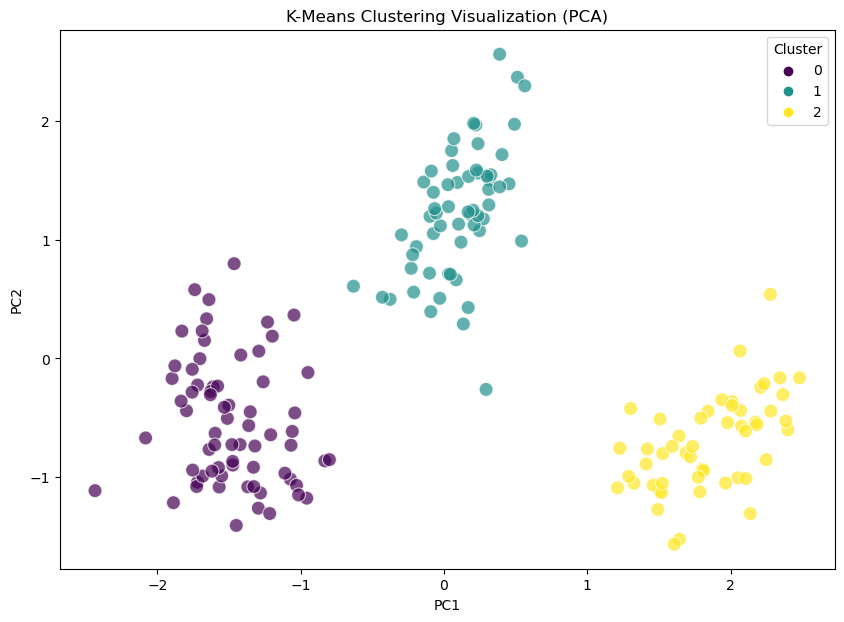

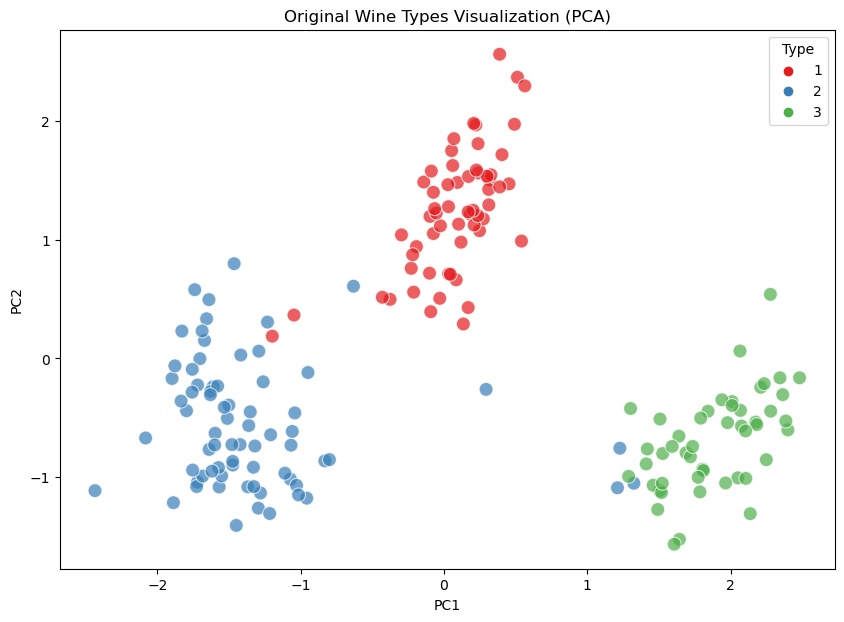

In [72]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
X = data.drop('Type', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
data['Cluster'] = clusters
silhouette = silhouette_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_scaled, clusters)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")

pca = PCA(n_components=5)
pca_results = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2','PC3','PC4','PC5'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('K-Means Clustering Visualization (PCA)')
plt.savefig('kmeans_clusters_pca.png')

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue=data['Type'], data=pca_df, palette='Set1', s=100, alpha=0.7)
plt.title('Original Wine Types Visualization (PCA)')
plt.savefig('original_types_pca.png')

C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


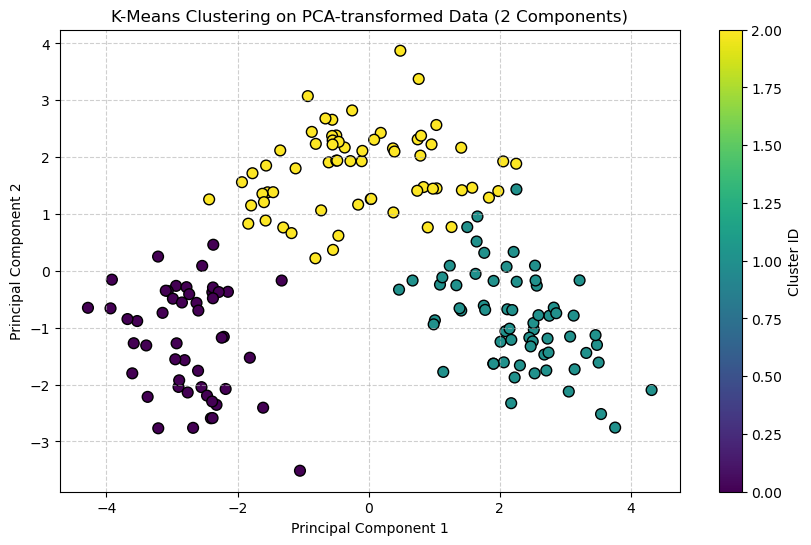

In [79]:
from sklearn.metrics import adjusted_rand_score, silhouette_score
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', edgecolor='k', s=60)
plt.title('K-Means Clustering on PCA-transformed Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('pca_clustering_results.png')

In [81]:
ari_orig_vs_true = adjusted_rand_score(y, clusters_orig)
ari_pca_vs_true = adjusted_rand_score(y, clusters_pca)
ari_orig_vs_pca = adjusted_rand_score(clusters_orig, clusters_pca)
silhouette_orig = silhouette_score(X_scaled, clusters_orig)
silhouette_pca = silhouette_score(X_pca, clusters_pca)

print(f"Adjusted Rand Index (Original vs Ground Truth): {ari_orig_vs_true:.4f}")
print(f"Adjusted Rand Index (PCA vs Ground Truth): {ari_pca_vs_true:.4f}")
print(f"Adjusted Rand Index (Original Clusters vs PCA Clusters): {ari_orig_vs_pca:.4f}")
print(f"Silhouette Score (Original): {silhouette_orig:.4f}")
print(f"Silhouette Score (PCA): {silhouette_pca:.4f}")

Adjusted Rand Index (Original vs Ground Truth): 0.8975
Adjusted Rand Index (PCA vs Ground Truth): 0.8951
Adjusted Rand Index (Original Clusters vs PCA Clusters): 0.9324
Silhouette Score (Original): 0.2849
Silhouette Score (PCA): 0.5611


1. Comparsion of results.
-> Accuracy in both methods achieved high agreement with ground truth(0.89).
->The clustering assingments were 93.2% identical.
->Seperation in Pca-transformed data (0.56) outperformed the original data(0.28),     indicating much cleraer and more compact clusters.
2. Key similarities and differences.
-> Similarity: Both methods identified the same three underlying groups of wine ,proving that the essential structure is preserved after  rdeuction.
-> Difference: The PCA clusters are visually and statistically more distinct,where the original data clusters have morelap due to high dimensional noise.
3. Impact of Dimensionality Reduction.
-> Noise Filtering: Reducing 13 features to 2 principal components removed redundant information, simplifying the data.
->Efficiency: PCA enhanced the performance of the K-Means algorithm by focusing on the dimensions with the highest variance, leading to better-defined cluster boundaries.
4.Traders-offs.
->PCA Approach: * Pros: Better visualization and higher cluster density.
->Original Dataset Approach: * Pros: Full data integrity and easier interpretation of feature influence.

1. Key findings.
->>Information retention
->>Clistering consistency
->>Quality Boost
2.practical Implications.
->>Efficience
->>Noise Removal
->>It visualizes 2D and 3D

3.Recommendations
->>Use PCA + Clustering when: Dealing with many features, looking for visual results, or prioritizing computational speed.
->>Use Clustering Directly when: Interpretability is the top priority (i.e., you need to explain the specific chemical reason for a grouping).
->>Best Practice: Use both—cluster on the original data for accuracy and interpretation, then use PCA for visualization and noise assessment.